In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/expense-pattern-income-vs-expensefamilyagearea/Income_expense_data.csv
/kaggle/input/expense-pattern-income-vs-expensefamilyagearea/data_dictionary.txt


##  Expense Pattern

### Track how spending changes across categories and over time.

In [2]:
df = pd.read_csv('/kaggle/input/expense-pattern-income-vs-expensefamilyagearea/Income_expense_data.csv')

In [3]:
df.head()

,REF_DATE,GEO,Statistic,Before-tax household income quintile,"Household expenditures, summary-level categories",UOM,COORDINATE,Expense,Family type,Age of older adult,Family income,Income
0,2010,Province 1,Average expenditure per household,All quintiles,Total expenditure,Dollars,C1,72075.0,Couple families,Total all ages,All income groups,7989380.0
1,2010,Province 1,Average expenditure per household,All quintiles,Food purchased from stores,Dollars,C2,5709.0,Couple families,Total all ages,"Under $10,000",189700.0
2,2010,Province 1,Average expenditure per household,All quintiles,Food purchased from restaurants,Dollars,C3,2141.0,Couple families,Total all ages,"$10,000 and over",7799670.0
3,2010,Province 1,Average expenditure per household,All quintiles,Shelter,Dollars,C4,15020.0,Couple families,Total all ages,"$15,000 and over",7695970.0
4,2010,Province 1,Average expenditure per household,All quintiles,Principal accommodation,Dollars,C5,13586.0,Couple families,Total all ages,"$20,000 and over",7552050.0


In [4]:
df.tail()

,REF_DATE,GEO,Statistic,Before-tax household income quintile,"Household expenditures, summary-level categories",UOM,COORDINATE,Expense,Family type,Age of older adult,Family income,Income
13255,2021,Province 13,Average expenditure per household,Highest quintile,Household furnishings,Dollars,C1322,2433.0,Couple families,55 to 64 years,"$70,000 and over",6160.0
13256,2021,Province 13,Average expenditure per household,Highest quintile,Household equipment,Dollars,C1323,2759.0,Couple families,55 to 64 years,"$75,000 and over",5940.0
13257,2021,Province 13,Average expenditure per household,Highest quintile,Household appliances,Dollars,C1324,1236.0,Couple families,55 to 64 years,"$80,000 and over",5650.0
13258,2021,Province 13,Average expenditure per household,Highest quintile,Clothing and accessories,Dollars,C1325,3941.0,Couple families,55 to 64 years,"$90,000 and over",5040.0
13259,2021,Province 13,Average expenditure per household,Highest quintile,Transportation,Dollars,C1326,17259.0,Couple families,55 to 64 years,Median total income,114560.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13260 entries, 0 to 13259
Data columns (total 12 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   REF_DATE                                          13260 non-null  int64  
 1   GEO                                               13260 non-null  object 
 2   Statistic                                         13260 non-null  object 
 3   Before-tax household income quintile              13260 non-null  object 
 4   Household expenditures, summary-level categories  13260 non-null  object 
 5   UOM                                               13260 non-null  object 
 6   COORDINATE                                        13260 non-null  object 
 7   Expense                                           13024 non-null  float64
 8   Family type                                       13260 non-null  object 
 9   Age of older adul

In [6]:
df.describe()

,REF_DATE,Expense,Income
count,13260.000000,13024.000000,1.325400e+04
mean,2014.800000,9628.216063,1.900229e+05
std,3.340785,21039.898472,7.889770e+05
min,2010.000000,65.000000,2.000000e+01
25%,2012.000000,1552.000000,4.740000e+03
50%,2014.500000,3195.500000,1.547000e+04
75%,2017.000000,8434.500000,4.330000e+04
max,2021.000000,221396.000000,8.980830e+06


In [7]:
df.isnull().sum()

REF_DATE                                              0
GEO                                                   0
Statistic                                             0
Before-tax household income quintile                  0
Household expenditures, summary-level categories      0
UOM                                                   0
COORDINATE                                            0
Expense                                             236
Family type                                           0
Age of older adult                                    0
Family income                                         0
Income                                                6
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

REF_DATE                                              int64
GEO                                                  object
Statistic                                            object
Before-tax household income quintile                 object
Household expenditures, summary-level categories     object
UOM                                                  object
COORDINATE                                           object
Expense                                             float64
Family type                                          object
Age of older adult                                   object
Family income                                        object
Income                                              float64
dtype: object

In [10]:
df.columns

Index(['REF_DATE', 'GEO', 'Statistic', 'Before-tax household income quintile',
       'Household expenditures, summary-level categories', 'UOM', 'COORDINATE',
       'Expense', 'Family type', 'Age of older adult', 'Family income',
       'Income'],
      dtype='object')

## Data visualizations

In [11]:
# Convert REF_DATE to datetime if it looks like a date
df['REF_DATE'] = pd.to_datetime(df['REF_DATE'], errors='coerce')

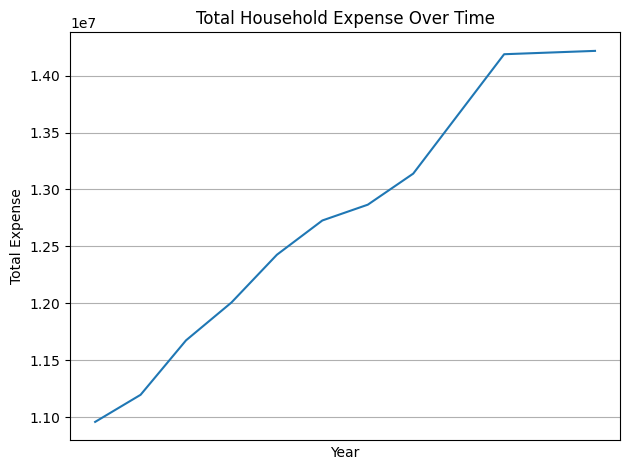

In [12]:
# 1. Expense Pattern Over Time
plt.figure()
expense_over_time = df.groupby('REF_DATE')['Expense'].sum()
expense_over_time.plot()
plt.title('Total Household Expense Over Time')
plt.xlabel('Year')
plt.ylabel('Total Expense')
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

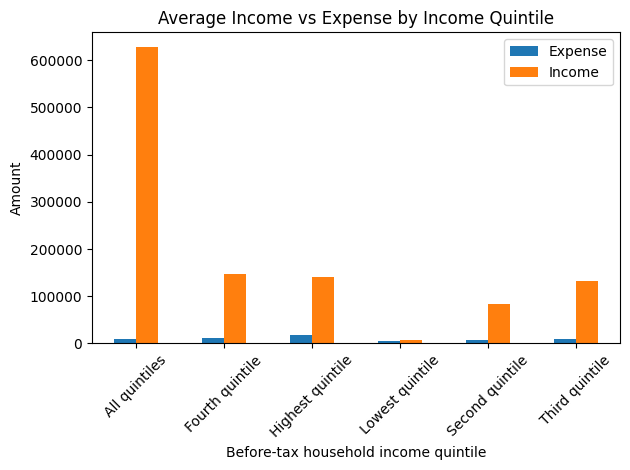

In [13]:
# 2. Income vs Expense by Quintile
plt.figure()
pivot_quintile = df.pivot_table(index='Before-tax household income quintile', 
                                 values=['Income', 'Expense'], aggfunc='mean')
pivot_quintile.plot(kind='bar')
plt.title('Average Income vs Expense by Income Quintile')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


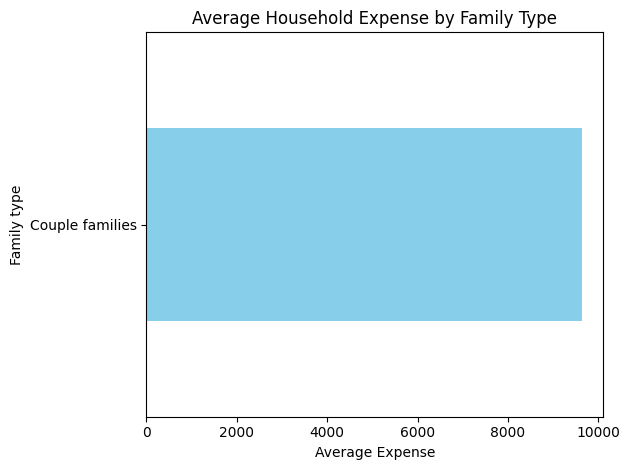

In [14]:
# 3. Expense by Family Type
plt.figure()
family_expense = df.groupby('Family type')['Expense'].mean().sort_values()
family_expense.plot(kind='barh', color='skyblue')
plt.title('Average Household Expense by Family Type')
plt.xlabel('Average Expense')
plt.tight_layout()
plt.show()

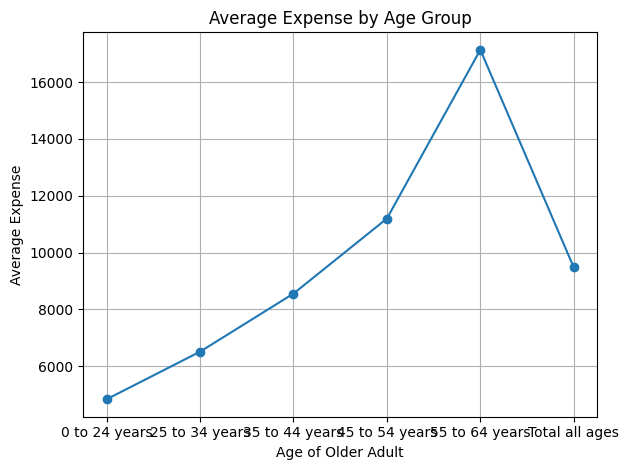

In [15]:
# 4. Expense by Age of Older Adult
plt.figure()
age_expense = df.groupby('Age of older adult')['Expense'].mean().sort_index()
age_expense.plot(marker='o')
plt.title('Average Expense by Age Group')
plt.xlabel('Age of Older Adult')
plt.ylabel('Average Expense')
plt.grid(True)
plt.tight_layout()
plt.show()

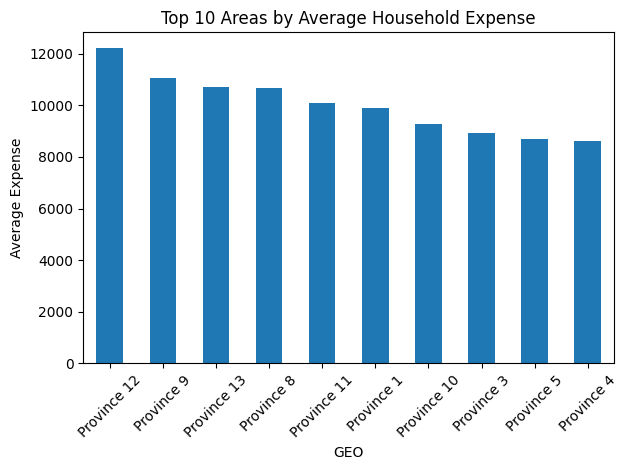

In [16]:
# 5. Expense by GEO (Area)
top_geo = df.groupby('GEO')['Expense'].mean().sort_values(ascending=False).head(10)
plt.figure()
top_geo.plot(kind='bar')
plt.title('Top 10 Areas by Average Household Expense')
plt.ylabel('Average Expense')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

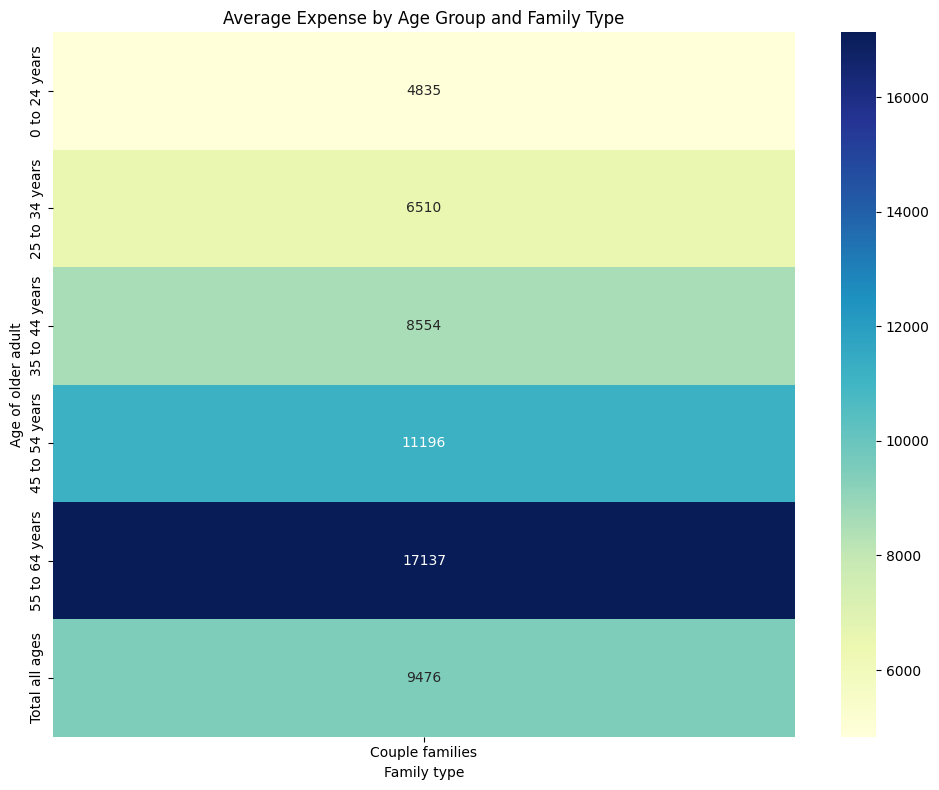

In [17]:
# Optional: Heatmap of Income vs Expense by Age and Family Type
pivot_heatmap = df.pivot_table(index='Age of older adult', 
                               columns='Family type', 
                               values='Expense', 
                               aggfunc='mean')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_heatmap, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Average Expense by Age Group and Family Type')
plt.tight_layout()
plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [19]:
# Drop rows with missing target or core feature values
df.dropna(subset=['Before-tax household income quintile', 'Expense', 'Income'], inplace=True)


In [20]:
# Create target: Encode income quintile into categories (0 to 4)
label_enc = LabelEncoder()
df['Income_Quintile_Label'] = label_enc.fit_transform(df['Before-tax household income quintile'])

In [21]:
# Features to use for prediction
features = ['Expense', 'Income', 'GEO', 'Statistic', 'Household expenditures, summary-level categories',
            'Family type', 'Age of older adult']

In [22]:
# Label encode categorical features
df_encoded = df[features].copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

In [23]:
# Target variable
y = df['Income_Quintile_Label']
X = df_encoded

In [24]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Classifiers to try
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}


In [26]:
results = {}

In [27]:
# Fit and evaluate all models
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    
    # Save results
    results[name] = acc * 100  # Convert to percentage

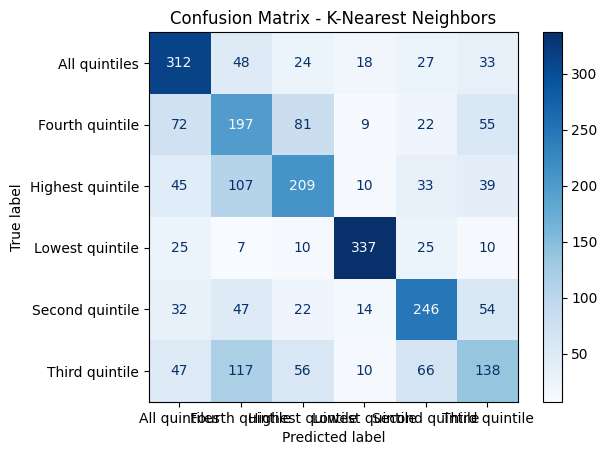

In [28]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_enc.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {name}')
plt.show()

In [29]:
# Display all accuracies
print("🔍 Model Accuracy Scores (in %):")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.2f}%")

🔍 Model Accuracy Scores (in %):
Logistic Regression: 22.62%
Decision Tree: 100.00%
Random Forest: 100.00%
Gradient Boosting: 100.00%
Support Vector Machine: 26.00%
Naive Bayes: 20.39%
K-Nearest Neighbors: 55.26%


## Thank you...pls upvote!!!!